# Experiment: Darcy FEM 421x421 Coarse/Fine Error Visualization

读取 Darcy paired 数据集，查看同一个 `coeff` 在粗网格和细网格 FEM 上得到的 `421 x 421` 统一采样解，以及它们的误差统计。


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

REPO_ROOT = Path('/inspire/hdd/global_user/zhouguancheng-253107140033/inspire_shared/Bias-Aware-FNO')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utilities3 import MatReader

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['image.cmap'] = 'viridis'


def latest_path(pattern: str) -> Path | None:
    matches = sorted(REPO_ROOT.glob(pattern), key=lambda p: p.stat().st_mtime)
    return matches[-1] if matches else None


def field_info(path: Path) -> dict[str, tuple[tuple[int, ...], str]]:
    try:
        info = {}
        for name, shape, dtype in scipy.io.whosmat(path):
            info[name] = (tuple(shape), dtype)
        return info
    except Exception:
        with h5py.File(path, 'r') as handle:
            return {key: (tuple(handle[key].shape), str(handle[key].dtype)) for key in handle.keys()}


def to_numpy(value):
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    return np.asarray(value)


def read_fields(path: Path, fields: list[str]) -> dict[str, np.ndarray]:
    reader = MatReader(str(path), to_torch=False, to_float=True)
    payload = {}
    for field in fields:
        payload[field] = to_numpy(reader.read_field(field))
    return payload


def scalar_value(array: np.ndarray) -> float:
    return float(np.asarray(array).reshape(-1)[0])


def relative_l2(pred: np.ndarray, target: np.ndarray) -> np.ndarray:
    diff = (pred - target).reshape(pred.shape[0], -1)
    ref = target.reshape(target.shape[0], -1)
    return np.linalg.norm(diff, axis=1) / np.clip(np.linalg.norm(ref, axis=1), 1e-12, None)


## Data Discovery


In [3]:
TRAIN_PATH = latest_path('data/darcy_fem_r*_train.mat')
TEST_PATH = latest_path('data/darcy_fem_r*_test.mat')
PRED_PATH = latest_path('pred/*darcy_eval.mat') or latest_path('pred/*fourier_2d_darcy*.mat')

print('TRAIN_PATH =', TRAIN_PATH)
print('TEST_PATH  =', TEST_PATH)
print('PRED_PATH  =', PRED_PATH)

assert TRAIN_PATH is not None, 'No Darcy train dataset found under data/'
assert TEST_PATH is not None, 'No Darcy test dataset found under data/'


TRAIN_PATH = /inspire/hdd/global_user/zhouguancheng-253107140033/inspire_shared/Bias-Aware-FNO/data/darcy_fem_r421_C256_F512_N1000_train.mat
TEST_PATH  = /inspire/hdd/global_user/zhouguancheng-253107140033/inspire_shared/Bias-Aware-FNO/data/darcy_fem_r421_C256_F512_N100_test.mat
PRED_PATH  = /inspire/hdd/global_user/zhouguancheng-253107140033/inspire_shared/Bias-Aware-FNO/pred/darcy_fem_r421_C256_F512_N1000_train_fourier_2d_darcy_N1000_ep1000_m12_w32_darcy_eval.mat


## Dataset Overview


In [4]:
train_info = field_info(TRAIN_PATH)
test_info = field_info(TEST_PATH)

for split_name, info in [('train', train_info), ('test', test_info)]:
    print(f'[{split_name}]')
    for key, (shape, dtype) in sorted(info.items()):
        print(f'  {key:18s} shape={shape} dtype={dtype}')
    print()

PAYLOAD_FIELDS = [
    'coeff',
    'sol_coarse',
    'sol_fine',
    'error_hf_lf',
    'mesh_coarse_points',
    'mesh_coarse_cells',
    'mesh_fine_points',
    'mesh_fine_cells',
    'grid_coords',
    'grf_alpha',
    'grf_tau',
    'coeff_low',
    'coeff_high',
    'coeff_resolution',
    'coarse_n',
    'fine_n',
]
train_payload = read_fields(TRAIN_PATH, PAYLOAD_FIELDS)
test_payload = read_fields(TEST_PATH, PAYLOAD_FIELDS)

metadata = {
    'coeff_resolution': int(scalar_value(train_payload['coeff_resolution'])),
    'coarse_n': int(scalar_value(train_payload['coarse_n'])),
    'fine_n': int(scalar_value(train_payload['fine_n'])),
    'grf_alpha': scalar_value(train_payload['grf_alpha']),
    'grf_tau': scalar_value(train_payload['grf_tau']),
    'coeff_low': scalar_value(train_payload['coeff_low']),
    'coeff_high': scalar_value(train_payload['coeff_high']),
}
metadata


[train]
  a_coarse           shape=(1000, 131072) dtype=float32
  a_fine             shape=(1000, 524288) dtype=float32
  coarse_n           shape=(1,) dtype=int32
  coeff              shape=(1000, 421, 421) dtype=float32
  coeff_high         shape=(1,) dtype=float32
  coeff_low          shape=(1,) dtype=float32
  coeff_resolution   shape=(1,) dtype=int32
  error_hf_lf        shape=(1000, 421, 421) dtype=float32
  fine_n             shape=(1,) dtype=int32
  grf_alpha          shape=(1,) dtype=float32
  grf_tau            shape=(1,) dtype=float32
  grid_coords        shape=(421,) dtype=float32
  mesh_coarse_cells  shape=(131072, 3) dtype=int32
  mesh_coarse_points shape=(66049, 2) dtype=float32
  mesh_fine_cells    shape=(524288, 3) dtype=int32
  mesh_fine_points   shape=(263169, 2) dtype=float32
  sol_coarse         shape=(1000, 421, 421) dtype=float32
  sol_fine           shape=(1000, 421, 421) dtype=float32

[test]
  a_coarse           shape=(100, 131072) dtype=single
  a_fine       

{'coeff_resolution': 421,
 'coarse_n': 256,
 'fine_n': 512,
 'grf_alpha': 2.0,
 'grf_tau': 3.0,
 'coeff_low': 4.0,
 'coeff_high': 12.0}

## Single Sample Comparison


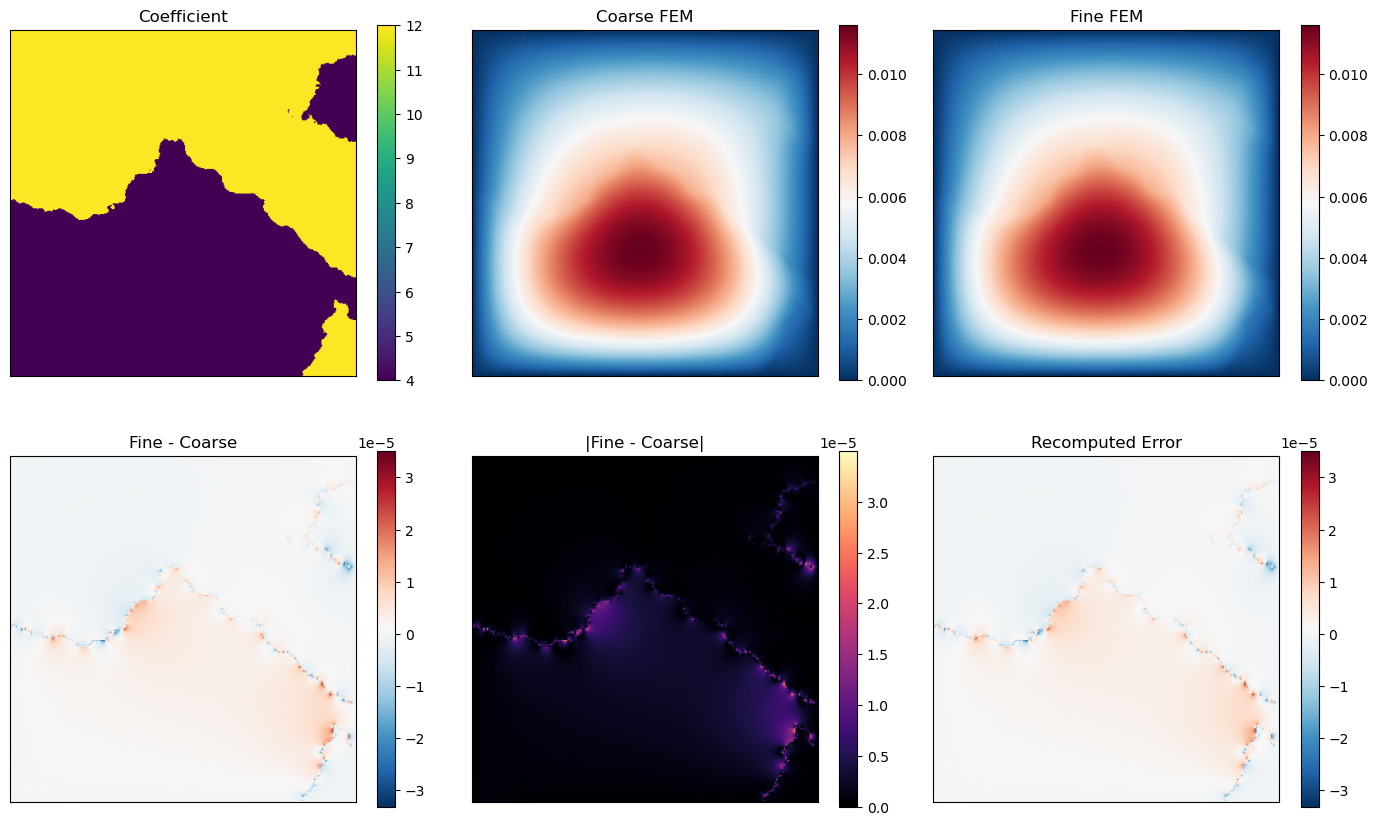

In [5]:
sample_index = 0
payload = train_payload
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
plots = [
    (payload['coeff'][sample_index], 'Coefficient', 'viridis'),
    (payload['sol_coarse'][sample_index], 'Coarse FEM', 'RdBu_r'),
    (payload['sol_fine'][sample_index], 'Fine FEM', 'RdBu_r'),
    (payload['error_hf_lf'][sample_index], 'Fine - Coarse', 'RdBu_r'),
    (np.abs(payload['error_hf_lf'][sample_index]), '|Fine - Coarse|', 'magma'),
    (payload['sol_fine'][sample_index] - payload['sol_coarse'][sample_index], 'Recomputed Error', 'RdBu_r'),
]
for ax, (field, title, cmap) in zip(axes.ravel(), plots):
    im = ax.imshow(field, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## Error Statistics


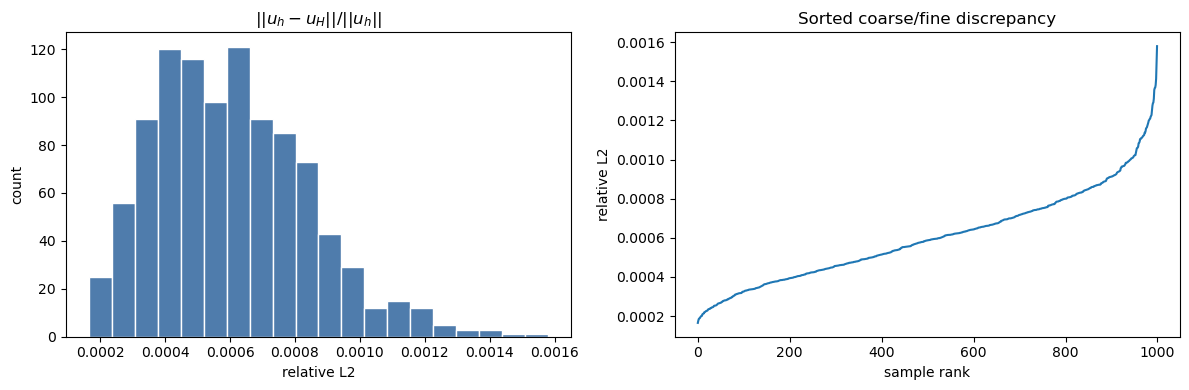

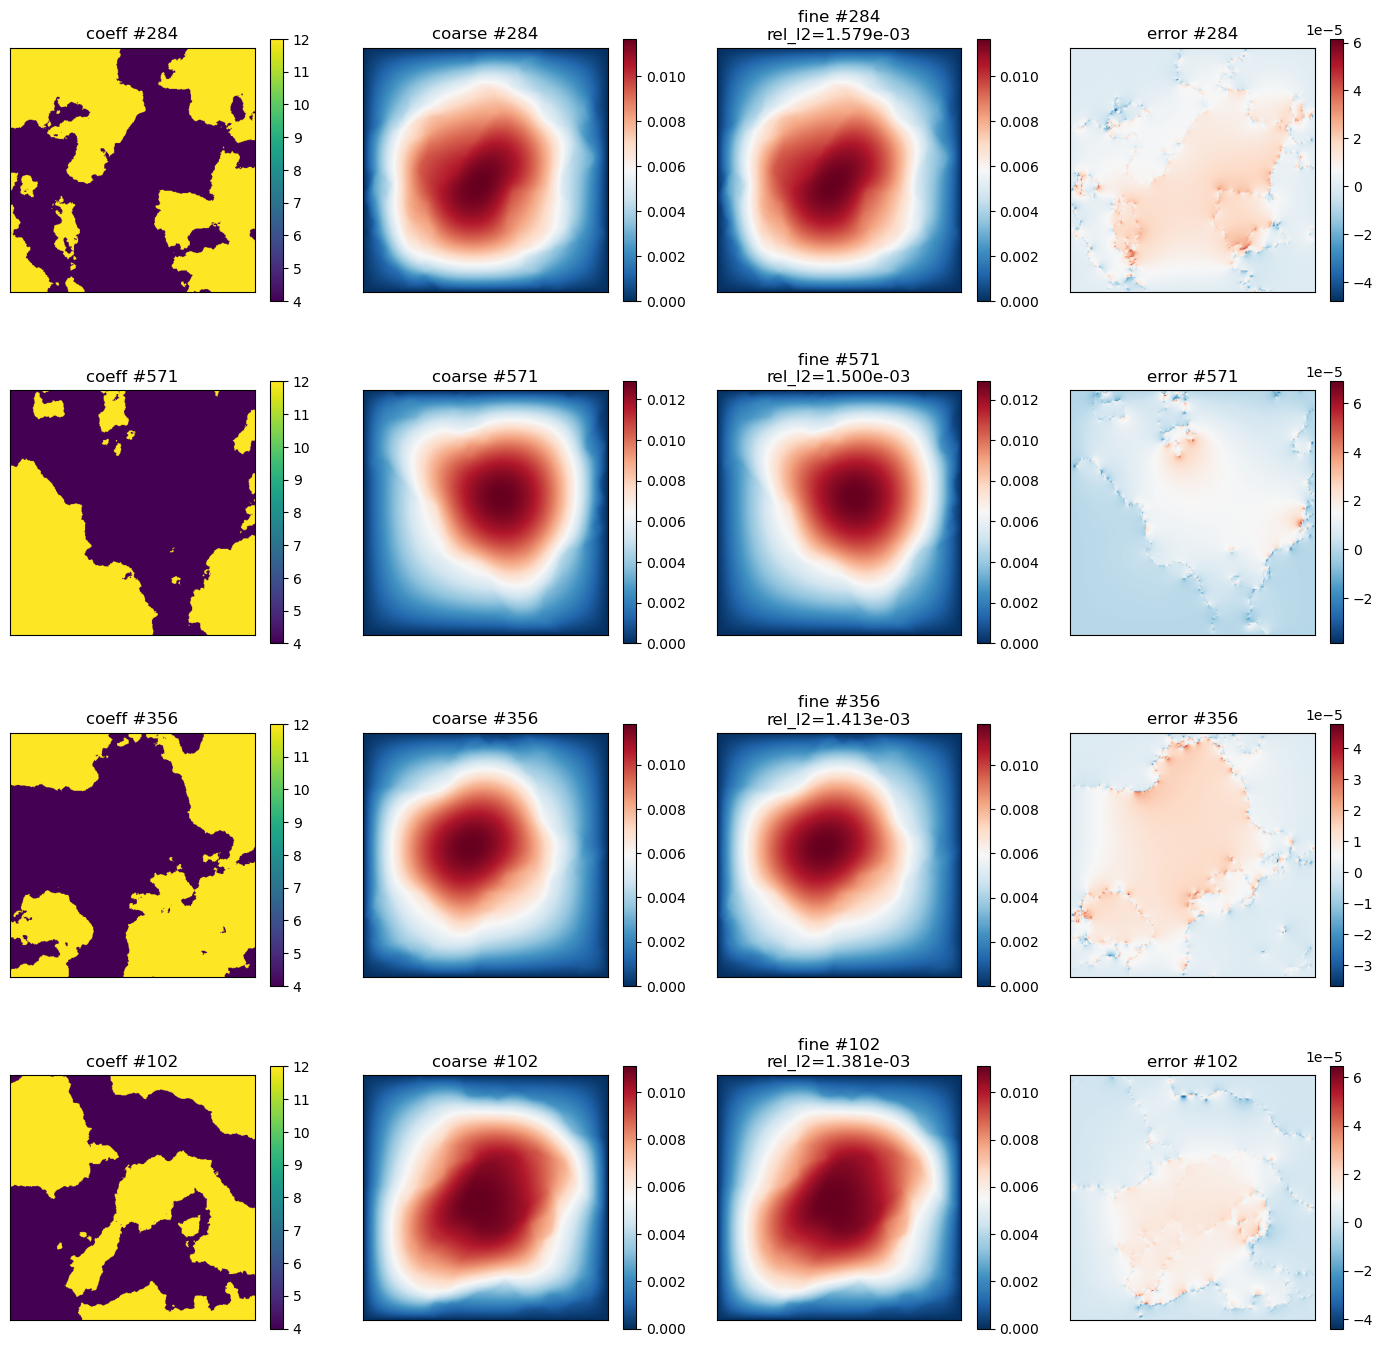

In [6]:
rel_errors = relative_l2(train_payload['sol_coarse'], train_payload['sol_fine'])
worst_indices = np.argsort(rel_errors)[-4:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rel_errors, bins=20, color="#4f7cac", edgecolor="white")
axes[0].set_title(r"$||u_h - u_H|| / ||u_h||$")
axes[0].set_xlabel("relative L2")
axes[0].set_ylabel("count")

axes[1].plot(np.sort(rel_errors))
axes[1].set_title("Sorted coarse/fine discrepancy")
axes[1].set_xlabel("sample rank")
axes[1].set_ylabel("relative L2")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(worst_indices), 4, figsize=(14, 3.5 * len(worst_indices)))
if len(worst_indices) == 1:
    axes = np.asarray([axes])
for row, idx in enumerate(worst_indices):
    row_plots = [
        (train_payload['coeff'][idx], f'coeff #{idx}', 'viridis'),
        (train_payload['sol_coarse'][idx], f'coarse #{idx}', 'RdBu_r'),
        (train_payload['sol_fine'][idx], f'fine #{idx}\nrel_l2={rel_errors[idx]:.3e}', 'RdBu_r'),
        (train_payload['error_hf_lf'][idx], f'error #{idx}', 'RdBu_r'),
    ]
    for ax, (field, title, cmap) in zip(axes[row], row_plots):
        im = ax.imshow(field, cmap=cmap)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## Mesh Overview


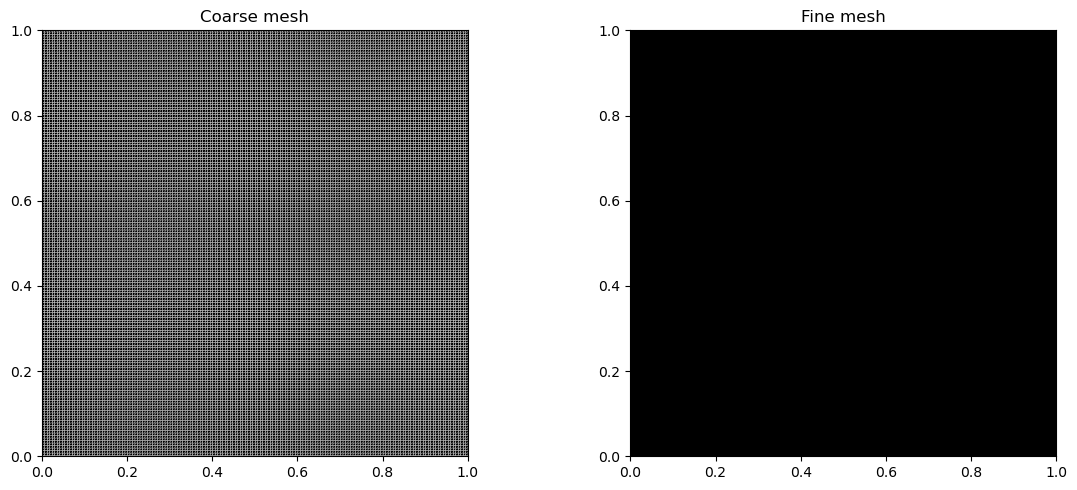

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, points, cells, title in [
    (axes[0], train_payload['mesh_coarse_points'], train_payload['mesh_coarse_cells'], 'Coarse mesh'),
    (axes[1], train_payload['mesh_fine_points'], train_payload['mesh_fine_cells'], 'Fine mesh'),
]:
    ax.triplot(points[:, 0], points[:, 1], cells, lw=0.2, color='black')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Prediction Comparison


Prediction file: /inspire/hdd/global_user/zhouguancheng-253107140033/inspire_shared/Bias-Aware-FNO/pred/darcy_fem_r421_C256_F512_N1000_train_fourier_2d_darcy_N1000_ep1000_m12_w32_darcy_eval.mat
coarse_l2_mean = 0.011698614805936813
fine_l2_mean   = 0.011699800379574299


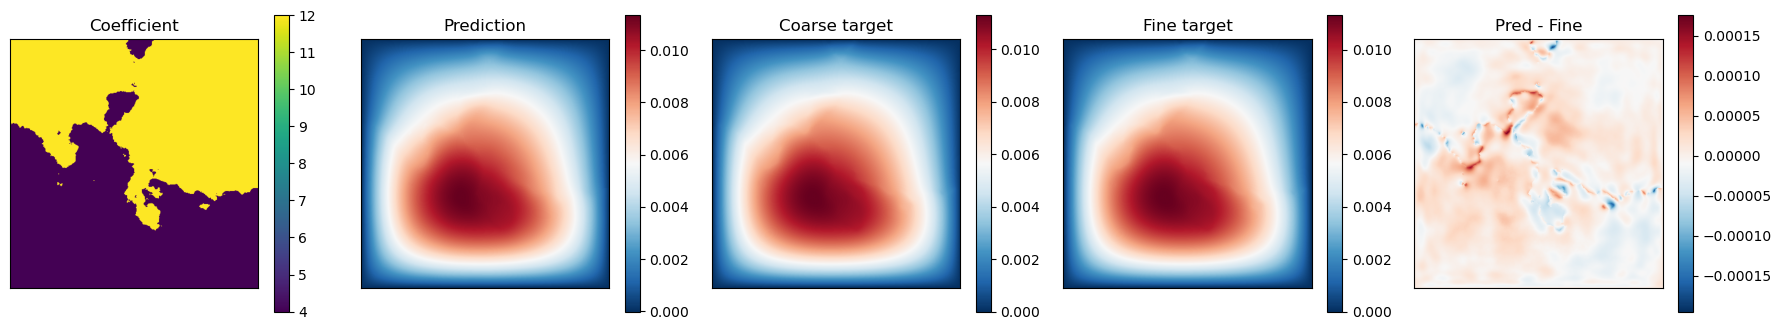

In [8]:
if PRED_PATH is None:
    print('No prediction file found under pred/.')
else:
    pred_fields = ['pred', 'target_coarse', 'target_fine', 'coeff', 'coarse_l2_mean', 'fine_l2_mean']
    pred_payload = read_fields(PRED_PATH, pred_fields)
    print('Prediction file:', PRED_PATH)
    print('coarse_l2_mean =', scalar_value(pred_payload['coarse_l2_mean']))
    print('fine_l2_mean   =', scalar_value(pred_payload['fine_l2_mean']))

    idx = 0
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    panels = [
        (pred_payload['coeff'][idx], 'Coefficient', 'viridis'),
        (pred_payload['pred'][idx], 'Prediction', 'RdBu_r'),
        (pred_payload['target_coarse'][idx], 'Coarse target', 'RdBu_r'),
        (pred_payload['target_fine'][idx], 'Fine target', 'RdBu_r'),
        (pred_payload['pred'][idx] - pred_payload['target_fine'][idx], 'Pred - Fine', 'RdBu_r'),
    ]
    for ax, (field, title, cmap) in zip(axes, panels):
        im = ax.imshow(field, cmap=cmap)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
